# Logaritmos Decimais

**Módulo:** 02 – Logaritmos (último notebook do módulo)

**Pré-requisitos:** [`0203a_logaritmos.ipynb`](0203a_logaritmos.ipynb) (logaritmo decimal, propriedades operatórias, antilogaritmo) e [`0205a_equacoes_exponenciais_e_logaritmicas.ipynb`](0205a_equacoes_exponenciais_e_logaritmicas.ipynb) (cálculo de logaritmos com Python)

**Objetivos de aprendizagem:**
- Compreender por que o logaritmo decimal foi historicamente o sistema escolhido para as tábuas de cálculo.
- Decompor um logaritmo decimal em característica e mantissa, determinando a característica a partir da posição da vírgula.
- Usar uma tábua de logaritmos, incluindo interpolação linear, para calcular logaritmos de números não tabelados exatamente.
- Comparar o processo histórico da tábua com o cálculo direto em Python, entendendo a evolução da ferramenta.

**Tempo estimado:** 70 a 90 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/02_logaritmos/0207a_logaritmos_decimais.ipynb)

## Antes das calculadoras, como se calculava um logaritmo?

No notebook anterior fechamos o problema do remédio com uma pergunta em aberto: antes das calculadoras, como as pessoas calculavam logaritmos — e, mais impressionante ainda, como usavam logaritmos para multiplicar e dividir números gigantescos rapidamente, sem errar uma vírgula?

A resposta, por mais de 300 anos, foram livros enormes cheios de números: as **tábuas de logaritmos**. Astrônomos calculando órbitas, navegadores determinando posições no oceano e engenheiros projetando pontes dependiam desses livros para transformar multiplicações demoradas em somas rápidas.

Ao final deste notebook, você vai saber ler uma tábua de logaritmos de verdade, do jeito que essas pessoas liam — e vai entender exatamente o que mudou quando a calculadora (e depois o Python) tomou o lugar delas.

📖 **Leitura complementar:** [Logaritmo comum](https://pt.wikipedia.org/wiki/Logaritmo_comum)

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)

## 1. Por que Logaritmo Decimal?

📌 **Definição formal:** o logaritmo decimal (base 10) já foi apresentado em `0203a_logaritmos` — é o log₁₀(x), denotado apenas log(x). Esse foi o sistema escolhido para construir tábuas de cálculo porque nosso sistema de numeração também é decimal: multiplicar ou dividir um número por uma potência de 10 apenas desloca a vírgula, sem alterar seus algarismos. Isso significa que

$$\log(10^n) = n$$

um resultado imediato que faz as potências de 10 se encaixarem naturalmente com deslocamentos de vírgula — a base de tudo que vamos construir neste notebook.

In [2]:
# log(10^n) = n é imediato, para qualquer n inteiro
for n in range(-2, 6):
    valor = 10.0**n
    print(f"log({valor:>10g}) = log(10^{n:>2}) = {math.log10(valor):.1f}")

log(      0.01) = log(10^-2) = -2.0
log(       0.1) = log(10^-1) = -1.0
log(         1) = log(10^ 0) = 0.0
log(        10) = log(10^ 1) = 1.0
log(       100) = log(10^ 2) = 2.0
log(      1000) = log(10^ 3) = 3.0
log(     10000) = log(10^ 4) = 4.0
log(    100000) = log(10^ 5) = 5.0


**Pergunta de checagem:** por que a base 10 é especialmente conveniente para se construir uma tábua de logaritmos "universal", que sirva para números de qualquer tamanho?

🎯 **Aplicação prática:** é a mesma ideia por trás da notação científica (vista em `0201a_potencias_e_raizes`) — todo número positivo pode ser escrito como (algo entre 1 e 10) × 10ⁿ. Essa decomposição é exatamente o ponto de partida da característica e da mantissa, que vamos ver a seguir.

## 2. Contexto Histórico: Napier, Briggs e a Era das Tábuas

🕵️ **Curiosidade histórica:** em 1614, o matemático escocês John Napier publicou a primeira tábua de logaritmos, fruto de mais de 20 anos de trabalho manual. Henry Briggs, professor em Londres, ficou tão impressionado que viajou até a Escócia para conhecer Napier pessoalmente. Juntos, os dois perceberam que um sistema baseado em **potências de 10** seria muito mais prático para cálculos do dia a dia do que o sistema original de Napier — e assim nasceu o logaritmo decimal que usamos até hoje. Briggs publicou sua própria tábua em 1624, e tábuas de logaritmos (cada vez mais precisas e completas) foram o principal instrumento de cálculo científico até meados do século XX.

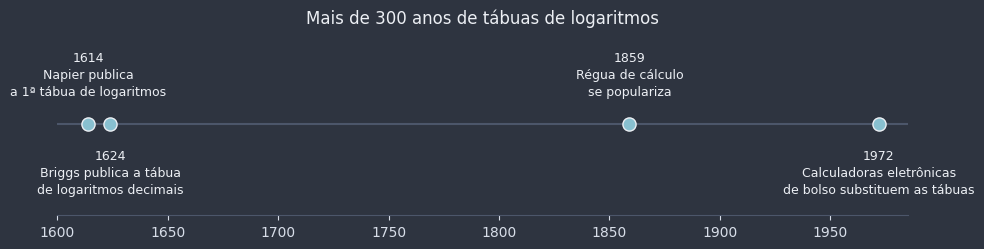

In [3]:
# Linha do tempo dos marcos históricos dos logaritmos decimais
eventos = [
    (1614, "Napier publica\na 1ª tábua de logaritmos"),
    (1624, "Briggs publica a tábua\nde logaritmos decimais"),
    (1859, "Régua de cálculo\nse populariza"),
    (1972, "Calculadoras eletrônicas\nde bolso substituem as tábuas"),
]

fig, ax = plt.subplots(figsize=(10, 2.6))
fig.patch.set_facecolor(NORD_FUNDO)
ax.set_facecolor(NORD_FUNDO)

anos = [ano for ano, _ in eventos]
ax.axhline(0, color=NORD_LINHA, linewidth=1.5, zorder=1)
ax.scatter(anos, [0] * len(anos), s=90, color=COR_PONTO, zorder=2, edgecolor=NORD_TEXTO)

for i, (ano, rotulo) in enumerate(eventos):
    deslocamento = 1 if i % 2 == 0 else -1
    ax.annotate(
        f"{ano}\n{rotulo}",
        (ano, 0),
        textcoords="offset points",
        xytext=(0, 35 * deslocamento),
        ha="center",
        va="center",
        color=NORD_TEXTO,
        fontsize=9,
        linespacing=1.4,
    )

ax.set_ylim(-1.3, 1.3)
ax.set_xlim(1600, 1985)
ax.set_yticks([])
ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_color(NORD_LINHA)
ax.tick_params(colors=NORD_TEXTO_SEC)
ax.set_title("Mais de 300 anos de tábuas de logaritmos", color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

**Pergunta de checagem:** por que a colaboração entre Napier e Briggs foi tão importante para a adoção dos logaritmos na Europa?

🎯 **Aplicação prática:** essas tábuas foram usadas por astrônomos, navegadores e engenheiros por mais de 300 anos, antes das calculadoras eletrônicas — Kepler, por exemplo, usou tábuas de logaritmos para calcular as órbitas planetárias.

📖 **Leitura complementar:** [John Napier](https://pt.wikipedia.org/wiki/John_Napier)

## 3. Característica e Mantissa: Conceito

📌 **Definição formal:** todo logaritmo decimal de um número positivo pode ser escrito como

$$\log(x) = \underbrace{\text{parte inteira}}_{\text{característica}} + \underbrace{\text{parte decimal}}_{\text{mantissa}}$$

A **mantissa** é sempre a mesma para números com os mesmos algarismos significativos — só muda a **característica**, conforme a posição da vírgula. Isso acontece porque multiplicar um número por uma potência de 10 soma um inteiro ao seu logaritmo (bloco 1), sem alterar a parte decimal. Por isso as tábuas só precisavam listar mantissas de números entre 1 e 10: todo o resto é a mesma mantissa, com a característica ajustada.

In [4]:
# log(345), log(34,5) e log(3450): mesma mantissa, característica diferente
for numero in [345, 34.5, 3450]:
    log_numero = math.log10(numero)
    caracteristica = math.floor(log_numero)
    mantissa = log_numero - caracteristica
    print(f"log({numero:>6g}) = {log_numero:.6f}  ->  característica = {caracteristica:>2}, mantissa = {mantissa:.6f}")

log(   345) = 2.537819  ->  característica =  2, mantissa = 0.537819
log(  34.5) = 1.537819  ->  característica =  1, mantissa = 0.537819
log(  3450) = 3.537819  ->  característica =  3, mantissa = 0.537819


🕹️ **Widget interativo:** digite um número positivo e veja sua decomposição em característica e mantissa.

In [5]:
def decompor_caracteristica_mantissa(numero: float) -> None:
    if numero <= 0:
        print("o logaritmo só está definido para números positivos.")
        return

    log_numero = math.log10(numero)
    caracteristica = math.floor(log_numero)
    mantissa = log_numero - caracteristica

    print(f"log({numero:g}) = {log_numero:.6f}")
    print(f"  característica (parte inteira) = {caracteristica}")
    print(f"  mantissa (parte decimal)       = {mantissa:.6f}")
    print(f"  conferindo: {caracteristica} + {mantissa:.6f} = {caracteristica + mantissa:.6f}")


widgets.interact(
    decompor_caracteristica_mantissa,
    numero=widgets.FloatText(value=345.0, description="número:"),
)

interactive(children=(FloatText(value=345.0, description='número:'), Output()), _dom_classes=('widget-interact…

<function __main__.decompor_caracteristica_mantissa(numero: float) -> None>

**Pergunta de checagem:** por que a mantissa não muda quando deslocamos a vírgula decimal de um número, mantendo os mesmos algarismos?

🎯 **Aplicação prática:** essa é a ideia central que tornou as tábuas práticas — não era preciso uma tábua "infinita", apenas uma cobrindo os números de 1 a 10.

## 4. Regras da Característica

📌 **Definição formal:** a característica pode ser determinada **sem calcular o logaritmo completo**, só observando a estrutura do número:

- Para números **≥ 1**: característica = (número de dígitos da parte inteira) − 1.
- Para números **entre 0 e 1**: a característica é **negativa**, determinada pela posição do primeiro algarismo significativo após a vírgula (1 casa depois da vírgula → característica −1; 2 casas → característica −2; e assim por diante).

In [6]:
# Determinando a característica só pela estrutura do número, e conferindo com Python
numeros = [345, 3_450_000, 0.0345, 0.345]
digitos_estimados = ["3 dígitos -> característica 2", "7 dígitos -> característica 6",
                      "1º algarismo na 2ª casa decimal -> característica -2",
                      "1º algarismo na 1ª casa decimal -> característica -1"]

for numero, estimativa in zip(numeros, digitos_estimados):
    caracteristica_real = math.floor(math.log10(numero))
    print(f"{numero:<12g} ({estimativa})  ->  característica real = {caracteristica_real}")

345          (3 dígitos -> característica 2)  ->  característica real = 2
3.45e+06     (7 dígitos -> característica 6)  ->  característica real = 6
0.0345       (1º algarismo na 2ª casa decimal -> característica -2)  ->  característica real = -2
0.345        (1º algarismo na 1ª casa decimal -> característica -1)  ->  característica real = -1


🕹️ **Widget interativo:** digite um número e veja o raciocínio passo a passo para determinar sua característica.

In [7]:
def calcular_caracteristica_passo_a_passo(numero: float) -> None:
    if numero <= 0:
        print("o logaritmo só está definido para números positivos.")
        return

    texto_numero = f"{numero:g}"
    if numero >= 1:
        n_digitos_parte_inteira = len(str(int(numero)))
        caracteristica = n_digitos_parte_inteira - 1
        print(f"{texto_numero} tem {n_digitos_parte_inteira} dígito(s) na parte inteira")
        print(f"característica = {n_digitos_parte_inteira} - 1 = {caracteristica}")
    else:
        casas_ate_1o_significativo = -math.floor(math.log10(numero)) - 1
        caracteristica = -(casas_ate_1o_significativo + 1)
        print(f"{texto_numero} tem seu 1º algarismo significativo na {casas_ate_1o_significativo + 1}ª casa decimal")
        print(f"característica = -{casas_ate_1o_significativo + 1} = {caracteristica}")

    print(f"\nconferindo com math.log10: floor(log10({texto_numero})) = {math.floor(math.log10(numero))}")


widgets.interact(
    calcular_caracteristica_passo_a_passo,
    numero=widgets.FloatText(value=3450.0, description="número:"),
)

interactive(children=(FloatText(value=3450.0, description='número:'), Output()), _dom_classes=('widget-interac…

<function __main__.calcular_caracteristica_passo_a_passo(numero: float) -> None>

**Pergunta de checagem:** qual é a característica de um número entre 0 e 1, e por que ela é negativa?

🎯 **Aplicação prática:** essa técnica permitia estimar rapidamente a "ordem de grandeza" de um resultado, mesmo antes de consultar a tábua para o valor exato — útil até hoje para conferir se uma resposta calculada faz sentido.

## 5. Mantissa: Como Consultar na Tábua

📌 **Definição formal:** a mantissa de um número é o logaritmo do número **normalizado** (reescrito entre 1 e 10, ignorando a vírgula). As tábuas tradicionais organizavam essas mantissas numa grade: as **linhas** traziam os dois primeiros algarismos significativos do número (de 10 a 99, representando 1,0 a 9,9) e as **colunas** traziam o terceiro algarismo (0 a 9) — assim, cruzando linha e coluna, chegava-se à mantissa de qualquer número de três algarismos significativos entre 1,00 e 9,99.

Abaixo, geramos com Python uma fatia simplificada dessa tábua, cobrindo os números de 3,00 a 3,99 — o suficiente para os exemplos que já vimos (345, 34,5, 3450, todos com os algarismos 3-4-5).

In [8]:
# Tábua simplificada: linhas = dois primeiros algarismos (30 a 39, representando 3,0 a 3,9)
# colunas = terceiro algarismo (0 a 9); célula = mantissa de (linha/10 + coluna/100)
linhas = list(range(30, 40))
colunas = list(range(10))

tabua_simplificada = pd.DataFrame(
    {coluna: [round(math.log10(linha / 10 + coluna / 100), 4) for linha in linhas] for coluna in colunas},
    index=linhas,
)
tabua_simplificada.index.name = "linha"
tabua_simplificada.columns.name = "coluna (3º algarismo)"
tabua_simplificada

coluna (3º algarismo),0,1,2,3,4,5,6,7,8,9
linha,,,,,,,,,,
30,0.4771,0.4786,0.4800,0.4814,0.4829,0.4843,0.4857,0.4871,0.4886,0.4900
31,0.4914,0.4928,0.4942,0.4955,0.4969,0.4983,0.4997,0.5011,0.5024,0.5038
32,0.5051,0.5065,0.5079,0.5092,0.5105,0.5119,0.5132,0.5145,0.5159,0.5172
33,0.5185,0.5198,0.5211,0.5224,0.5237,0.5250,0.5263,0.5276,0.5289,0.5302
34,0.5315,0.5328,0.5340,0.5353,0.5366,0.5378,0.5391,0.5403,0.5416,0.5428
35,0.5441,0.5453,0.5465,0.5478,0.5490,0.5502,0.5514,0.5527,0.5539,0.5551
36,0.5563,0.5575,0.5587,0.5599,0.5611,0.5623,0.5635,0.5647,0.5658,0.5670
37,0.5682,0.5694,0.5705,0.5717,0.5729,0.5740,0.5752,0.5763,0.5775,0.5786
38,0.5798,0.5809,0.5821,0.5832,0.5843,0.5855,0.5866,0.5877,0.5888,0.5899


🕹️ **Widget interativo:** escolha os três algarismos de um número entre 3,00 e 3,99 e veja onde ele estaria na tábua, com a linha e a coluna destacadas.

In [ ]:
def destacar_na_tabua(segundo_algarismo: int, terceiro_algarismo: int) -> None:
    linha = 30 + segundo_algarismo
    coluna = terceiro_algarismo
    numero = linha / 10 + coluna / 100
    mantissa = tabua_simplificada.loc[linha, coluna]

    fig, ax = plt.subplots(figsize=(9, 4.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    ax.set_facecolor(NORD_FUNDO)
    ax.axis("off")

    tabela = ax.table(
        cellText=tabua_simplificada.values,
        rowLabels=tabua_simplificada.index,
        colLabels=tabua_simplificada.columns,
        cellLoc="center",
        loc="center",
    )
    tabela.auto_set_font_size(False)
    tabela.set_fontsize(8)
    tabela.scale(1, 1.3)

    for (linha_cel, coluna_cel), celula in tabela.get_celld().items():
        celula.set_edgecolor(NORD_LINHA)
        if linha_cel == 0 or coluna_cel == -1:
            celula.set_facecolor(NORD_PAINEL)
            celula.set_text_props(color=NORD_TEXTO)
        else:
            celula.set_facecolor(NORD_FUNDO)
            celula.set_text_props(color=NORD_TEXTO_SEC)

    indice_linha = tabua_simplificada.index.get_loc(linha) + 1
    indice_coluna = tabua_simplificada.columns.get_loc(coluna)
    tabela[indice_linha, indice_coluna].set_facecolor(COR_DESTAQUE)
    tabela[indice_linha, indice_coluna].set_text_props(color=NORD_FUNDO, weight="bold")
    tabela[indice_linha, -1].set_facecolor(COR_SECUNDARIA)
    tabela[0, indice_coluna].set_facecolor(COR_SECUNDARIA)

    ax.set_title(
        f"número {numero:.2f}  ->  linha {linha} (2º algarismo), coluna {coluna} (3º algarismo)  ->  mantissa {mantissa:.4f}",
        color=NORD_TEXTO,
        fontsize=10,
    )
    plt.tight_layout()
    plt.show()


widgets.interact(
    destacar_na_tabua,
    segundo_algarismo=widgets.IntSlider(value=4, min=0, max=9, description="2º alg.:"),
    terceiro_algarismo=widgets.IntSlider(value=5, min=0, max=9, description="3º alg.:"),
)

interactive(children=(IntSlider(value=4, description='2º alg.:', max=9), IntSlider(value=5, description='3º al…

<function __main__.destacar_na_tabua(segundo_algarismo: int, terceiro_algarismo: int) -> None>

**Pergunta de checagem:** por que a tábua só precisa cobrir os números de 1,00 a 9,99, e não todos os números possíveis?

## 6. Passo a Passo: Usando uma Tábua de Logaritmos

📌 **Definição formal:** juntando característica e mantissa, o processo completo de consultar um logaritmo numa tábua tem quatro passos:

1. Determinar a **característica**, pela posição da vírgula (bloco 4).
2. Normalizar o número para a forma "entre 1 e 10", identificando os três primeiros algarismos significativos.
3. Consultar a **mantissa** na tábua, cruzando linha (2 primeiros algarismos) e coluna (3º algarismo) (bloco 5).
4. Somar característica + mantissa.

O caminho inverso — dado um logaritmo, encontrar o número original — é o **antilogaritmo** (já visto em `0203a_logaritmos`): separa-se característica e mantissa, procura-se a mantissa na tábua (agora "de trás para frente") e usa-se a característica para reposicionar a vírgula.

In [10]:
# Passo a passo completo: log(3450)
numero = 3450

print(f"1) característica: {numero} tem {len(str(numero))} dígitos -> característica = {len(str(numero)) - 1}")
caracteristica = len(str(numero)) - 1

normalizado = numero / 10**caracteristica
print(f"2) normalizando: {numero} = {normalizado:g} x 10^{caracteristica}")

linha, coluna = 34, 5
mantissa = tabua_simplificada.loc[linha, coluna]
print(f"3) consultando a tábua: linha {linha}, coluna {coluna} -> mantissa = {mantissa}")

log_pela_tabua = caracteristica + mantissa
print(f"4) log({numero}) = {caracteristica} + {mantissa} = {log_pela_tabua}")
print(f"\nconferindo com Python: math.log10({numero}) = {math.log10(numero):.4f}")

# Caminho inverso: antilogaritmo de 3,5378 usando a tábua "de trás para frente"
log_alvo = 3.5378
caracteristica_alvo = math.floor(log_alvo)
mantissa_alvo = round(log_alvo - caracteristica_alvo, 4)

diferencas = (tabua_simplificada - mantissa_alvo).abs()
linha_encontrada, coluna_encontrada = diferencas.stack().idxmin()
numero_normalizado_encontrado = linha_encontrada / 10 + coluna_encontrada / 100
antilogaritmo = numero_normalizado_encontrado * 10**caracteristica_alvo

print(f"\nantilogaritmo de {log_alvo}:")
print(f"  característica = {caracteristica_alvo}, mantissa = {mantissa_alvo}")
print(f"  mantissa mais próxima na tábua: linha {linha_encontrada}, coluna {coluna_encontrada} -> {numero_normalizado_encontrado:.2f}")
print(f"  antilog({log_alvo}) ≈ {numero_normalizado_encontrado:.2f} x 10^{caracteristica_alvo} = {antilogaritmo:.0f}")
print(f"  conferindo com Python: 10^{log_alvo} = {10**log_alvo:.1f}")

1) característica: 3450 tem 4 dígitos -> característica = 3
2) normalizando: 3450 = 3.45 x 10^3
3) consultando a tábua: linha 34, coluna 5 -> mantissa = 0.5378
4) log(3450) = 3 + 0.5378 = 3.5378

conferindo com Python: math.log10(3450) = 3.5378

antilogaritmo de 3.5378:
  característica = 3, mantissa = 0.5378
  mantissa mais próxima na tábua: linha 34, coluna 5 -> 3.45
  antilog(3.5378) ≈ 3.45 x 10^3 = 3450
  conferindo com Python: 10^3.5378 = 3449.8


🕹️ **Widget interativo:** um simulador passo a passo — escolha um número entre 3,00 e 3,99 e veja cada etapa da consulta à tábua, como um "assistente" guiando o processo.

In [11]:
def simulador_tabua(numero: float) -> None:
    linha = int(numero * 10)
    coluna = round((numero * 100)) % 10
    numero_tabua = linha / 10 + coluna / 100

    caracteristica = 0  # todo número entre 3,00 e 3,99 já está normalizado (entre 1 e 10)
    mantissa = tabua_simplificada.loc[linha, coluna]

    print("passo 1 - característica: o número já está entre 1 e 10, então característica = 0")
    print(f"passo 2 - normalização: {numero_tabua:.2f} já é a forma normalizada (nada a fazer)")
    print(f"passo 3 - consulta à tábua: linha {linha}, coluna {coluna} -> mantissa = {mantissa}")
    print(f"passo 4 - soma final: log({numero_tabua:.2f}) = {caracteristica} + {mantissa} = {mantissa}")
    print(f"\nconferindo com Python: math.log10({numero_tabua:.2f}) = {math.log10(numero_tabua):.4f}")


widgets.interact(
    simulador_tabua,
    numero=widgets.FloatSlider(value=3.45, min=3.00, max=3.99, step=0.01, description="número:", readout_format=".2f"),
)

interactive(children=(FloatSlider(value=3.45, description='número:', max=3.99, min=3.0, step=0.01), Output()),…

<function __main__.simulador_tabua(numero: float) -> None>

**Pergunta de checagem:** em que etapa desse processo um pequeno erro de leitura poderia "estragar" o resultado final?

🎯 **Aplicação prática:** reproduzir o processo usado por engenheiros e cientistas para multiplicar números grandes, transformando a multiplicação numa soma de logaritmos (propriedade vista em `0203a_logaritmos`) e depois "desfazendo" com o antilogaritmo — é exatamente o que vamos fazer no exercício desafio deste notebook.

## 7. Interpolação Linear na Tábua

📌 **Definição formal:** e quando o número tem mais algarismos significativos do que a tábua cobre? Por exemplo, nossa tábua simplificada só tem passos de 0,01 (3,45, 3,46, ...) — mas e o número 3,457? A solução clássica é a **interpolação linear**: aproximamos a mantissa "entre" as duas linhas vizinhas da tábua, proporcionalmente à posição do número entre elas.

$$\text{mantissa}(x) \approx m_1 + \frac{x - x_1}{x_2 - x_1} \cdot (m_2 - m_1)$$

em que $x_1 < x < x_2$ são os dois valores vizinhos tabelados, com mantissas $m_1$ e $m_2$.

In [12]:
# Interpolando o logaritmo de 34570 (característica 4), usando os vizinhos 3,45 e 3,46
numero = 34570
caracteristica = len(str(numero)) - 1
normalizado = numero / 10**caracteristica  # 3,457

x1, x2 = 3.45, 3.46
m1 = tabua_simplificada.loc[34, 5]
m2 = tabua_simplificada.loc[34, 6]

fracao = (normalizado - x1) / (x2 - x1)
mantissa_interpolada = m1 + fracao * (m2 - m1)
log_interpolado = caracteristica + mantissa_interpolada

print(f"{numero} normalizado = {normalizado:g}, entre os vizinhos tabelados {x1} e {x2}")
print(f"mantissa({x1}) = {m1}   mantissa({x2}) = {m2}")
print(f"fração da distância entre os vizinhos: ({normalizado:g} - {x1})/({x2} - {x1}) = {fracao:.2f}")
print(f"mantissa interpolada = {m1} + {fracao:.2f} x ({m2} - {m1}) = {mantissa_interpolada:.4f}")
print(f"\nlog({numero}) pela tábua (com interpolação) = {caracteristica} + {mantissa_interpolada:.4f} = {log_interpolado:.4f}")
print(f"conferindo com Python: math.log10({numero}) = {math.log10(numero):.4f}")

34570 normalizado = 3.457, entre os vizinhos tabelados 3.45 e 3.46
mantissa(3.45) = 0.5378   mantissa(3.46) = 0.5391
fração da distância entre os vizinhos: (3.457 - 3.45)/(3.46 - 3.45) = 0.70
mantissa interpolada = 0.5378 + 0.70 x (0.5391 - 0.5378) = 0.5387

log(34570) pela tábua (com interpolação) = 4 + 0.5387 = 4.5387
conferindo com Python: math.log10(34570) = 4.5387


🕹️ **Widget interativo:** ajuste um número entre 3,450 e 3,459 e veja, visualmente, a reta que liga os dois vizinhos tabelados e o ponto interpolado sobre ela.

In [13]:
def visualizar_interpolacao(numero: float) -> None:
    x1, x2 = 3.45, 3.46
    m1 = tabua_simplificada.loc[34, 5]
    m2 = tabua_simplificada.loc[34, 6]

    fracao = (numero - x1) / (x2 - x1)
    mantissa_interpolada = m1 + fracao * (m2 - m1)
    mantissa_real = math.log10(numero)

    fig, ax = plt.subplots(figsize=(7, 5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)

    xs_curva = np.linspace(x1, x2, 200)
    ax.plot(xs_curva, np.log10(xs_curva), color=COR_SECUNDARIA, linewidth=1.5, linestyle="--", label="log(x) real")
    ax.plot([x1, x2], [m1, m2], color=COR_PONTO, linewidth=2, marker="o", label="reta de interpolação")
    ax.scatter([numero], [mantissa_interpolada], color=COR_DESTAQUE, s=90, zorder=5, label="valor interpolado")

    ax.annotate(f"{x1}\n{m1:.4f}", (x1, m1), textcoords="offset points", xytext=(-35, -10), color=NORD_TEXTO_SEC, fontsize=8)
    ax.annotate(f"{x2}\n{m2:.4f}", (x2, m2), textcoords="offset points", xytext=(10, -10), color=NORD_TEXTO_SEC, fontsize=8)
    ax.annotate(f"{numero:.3f}\n{mantissa_interpolada:.4f}", (numero, mantissa_interpolada),
                textcoords="offset points", xytext=(0, 12), color=NORD_TEXTO, fontsize=9, ha="center")

    ax.set_xlabel("número", color=NORD_TEXTO_SEC)
    ax.set_ylabel("mantissa", color=NORD_TEXTO_SEC)
    ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA, fontsize=9)
    plt.tight_layout()
    plt.show()

    erro = abs(mantissa_interpolada - mantissa_real)
    print(f"mantissa interpolada = {mantissa_interpolada:.6f}   mantissa real = {mantissa_real:.6f}   erro = {erro:.6f}")


widgets.interact(
    visualizar_interpolacao,
    numero=widgets.FloatSlider(value=3.457, min=3.450, max=3.459, step=0.001, description="número:", readout_format=".3f"),
)

interactive(children=(FloatSlider(value=3.457, description='número:', max=3.459, min=3.45, readout_format='.3f…

<function __main__.visualizar_interpolacao(numero: float) -> None>

**Pergunta de checagem:** por que a interpolação linear é uma boa aproximação para uma tábua de logaritmos, mesmo a função logarítmica não sendo uma reta?

🎯 **Aplicação prática:** a mesma técnica de interpolação linear é usada até hoje em engenharia e ciência de dados para estimar valores entre pontos conhecidos de uma tabela ou medição.

## 8. Comparação Tábua × Python e Fechamento do Módulo

🕵️ **Curiosidade histórica:** outro instrumento mecânico baseado em escalas logarítmicas foi a **régua de cálculo** — em vez de consultar uma tábua impressa, bastava deslizar duas réguas com escalas logarítmicas para "somar" logaritmos fisicamente. Foi o instrumento de cálculo dos engenheiros até os anos 1970, inclusive nos primeiros projetos da corrida espacial.

📌 **Conexão:** vamos comparar, passo a passo, o processo da tábua com o cálculo direto em Python, e fechar o módulo relembrando a jornada completa: potências e raízes → função exponencial → logaritmos → função logarítmica → equações → inequações → logaritmos decimais.

In [14]:
# Comparando o número de "passos de raciocínio" entre a tábua e o Python, para o mesmo número
numero = 3450

etapas_tabua = [
    f"1) característica: {numero} tem {len(str(numero))} dígitos -> característica = {len(str(numero)) - 1}",
    f"2) normalizar: {numero} = 3,45 x 10^{len(str(numero)) - 1}",
    "3) consultar a tábua: linha 34, coluna 5 -> mantissa = 0,5378",
    f"4) somar: log({numero}) = {len(str(numero)) - 1} + 0,5378 = {len(str(numero)) - 1 + 0.5378}",
]

print("== método da tábua ==")
for etapa in etapas_tabua:
    print(etapa)

print(f"\n== método Python ==")
print(f"1) math.log10({numero}) = {math.log10(numero):.4f}")

print(f"\n{len(etapas_tabua)} passos manuais (com risco de erro de leitura em cada um) contra 1 linha de código, exata e instantânea.")

== método da tábua ==
1) característica: 3450 tem 4 dígitos -> característica = 3
2) normalizar: 3450 = 3,45 x 10^3
3) consultar a tábua: linha 34, coluna 5 -> mantissa = 0,5378
4) somar: log(3450) = 3 + 0,5378 = 3.5378

== método Python ==
1) math.log10(3450) = 3.5378

4 passos manuais (com risco de erro de leitura em cada um) contra 1 linha de código, exata e instantânea.


🕹️ **Widget interativo:** escolha um número entre 3,00 e 3,99 e compare, lado a lado, o número de etapas do método da tábua contra o método direto em Python.

In [ ]:
def comparar_metodos(numero: float) -> None:
    linha = int(numero * 10)
    coluna = round(numero * 100) % 10
    mantissa = tabua_simplificada.loc[linha, coluna]

    print(f"tábua:  característica=0 -> consultar linha {linha}/coluna {coluna} -> mantissa={mantissa} -> somar  (4 etapas)")
    print(f"python: math.log10({numero:.2f}) = {math.log10(numero):.4f}  (1 etapa)")

    fig, ax = plt.subplots(figsize=(5, 3.2))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)

    metodos = ["tábua\n(manual)", "python\n(math.log10)"]
    n_etapas = [4, 1]
    cores = [COR_ALERTA, COR_DESTAQUE]
    ax.bar(metodos, n_etapas, color=cores, edgecolor=NORD_TEXTO)
    ax.set_ylabel("nº de etapas (ilustrativo)", color=NORD_TEXTO_SEC)
    ax.set_ylim(0, 5)
    plt.tight_layout()
    plt.show()


widgets.interact(
    comparar_metodos,
    numero=widgets.FloatSlider(value=3.45, min=3.00, max=3.99, step=0.01, description="número:", readout_format=".2f"),
)

interactive(children=(FloatSlider(value=3.45, description='número:', max=3.99, min=3.0, step=0.01), Output()),…

<function __main__.comparar_metodos(numero: float) -> None>

**Pergunta de checagem:** o que mudou, na prática da matemática e da ciência, quando as calculadoras eletrônicas substituíram as tábuas de logaritmos?

🎯 **Aplicação prática:** é o próprio fechamento do notebook e do módulo — um panorama histórico e tecnológico completo, do papel ao `math.log10`.

📖 **Leitura complementar:** [Régua de cálculo](https://pt.wikipedia.org/wiki/R%C3%A9gua_de_c%C3%A1lculo)

## Resumo — cheat sheet

| Conceito | Ideia-chave |
|---|---|
| Por que base 10 | log(10ⁿ) = n; encaixa naturalmente no nosso sistema de numeração decimal |
| log(x) = característica + mantissa | característica = parte inteira, mantissa = parte decimal (sempre ≥ 0) |
| Característica (x ≥ 1) | (nº de dígitos da parte inteira) − 1 |
| Característica (0 < x < 1) | negativa; determinada pela posição do 1º algarismo significativo após a vírgula |
| Mantissa | depende só dos algarismos significativos, não da posição da vírgula — é o log do número normalizado (entre 1 e 10) |
| Tábua de logaritmos | linhas = 2 primeiros algarismos, colunas = 3º algarismo, célula = mantissa |
| Interpolação linear | aproxima a mantissa de um valor não tabelado, "entre" duas linhas vizinhas da tábua |
| Antilogaritmo pela tábua | mesmo processo "de trás para frente": mantissa -> número normalizado -> reposicionar a vírgula com a característica |
| Hoje | `math.log10` calcula em milissegundos o que uma tábua levava minutos para resolver — mesma matemática, ferramenta diferente |

## Exercícios

**Básico**
1. Decomponha um logaritmo em característica e mantissa.
2. Determine a característica de números apenas observando sua estrutura (sem calcular o logaritmo completo).

**Intermediário**
3. Consulte a tábua simplificada para calcular um logaritmo por leitura direta (sem interpolação).
4. Calcule um antilogaritmo, decompondo em característica e mantissa e revertendo com a tábua.

**Desafio**
5. Reproduza um cálculo histórico: multiplique dois números usando logaritmo e antilogaritmo, e compare com o resultado direto.

Gabarito completo com resolução passo a passo em [`0207b_logaritmos_decimais_gabarito.ipynb`](0207b_logaritmos_decimais_gabarito.ipynb) — tente resolver sozinho antes de olhar.

### Básico

In [ ]:
# Exercício Básico 1: decomponha log(4780) em característica e mantissa.
# Guarde como tupla (caracteristica, mantissa), com a mantissa arredondada a 4 casas decimais.
decomposicao_exercicio1 = ...  # ex: (a, b)

print(decomposicao_exercicio1)

In [ ]:
# Verificação
log_esperado = math.log10(4780)
caracteristica_esperada = math.floor(log_esperado)
mantissa_esperada = round(log_esperado - caracteristica_esperada, 4)
assert decomposicao_exercicio1 == (caracteristica_esperada, mantissa_esperada), (
    "Tente de novo, revise: separe log(4780) em parte inteira (característica) e parte "
    "decimal (mantissa), arredondando a mantissa a 4 casas decimais (seção 3 - Característica e Mantissa: Conceito)."
)
print("Certo!")

In [ ]:
# Exercício Básico 2: determine a característica de 27300 e de 0,0058, apenas observando
# a estrutura de cada número (sem calcular o logaritmo completo).
# Guarde como tupla (caracteristica_1, caracteristica_2).
caracteristicas_exercicio2 = ...  # ex: (a, b)

print(caracteristicas_exercicio2)

In [ ]:
# Verificação
esperado = (math.floor(math.log10(27300)), math.floor(math.log10(0.0058)))
assert caracteristicas_exercicio2 == esperado, (
    "Tente de novo, revise: 27300 tem 5 dígitos na parte inteira (característica = 5-1=4); "
    "0,0058 tem seu 1º algarismo significativo na 3ª casa decimal (característica = -3) "
    "(seção 4 - Regras da Característica)."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: usando a tábua simplificada (tabua_simplificada, seção 5),
# calcule log(347) por consulta direta (sem interpolação).
# Guarde o resultado (característica + mantissa da tábua) em log_exercicio3 (float).
log_exercicio3 = ...

print(log_exercicio3)

In [ ]:
# Verificação
mantissa_tabua = tabua_simplificada.loc[34, 7]
esperado = 2 + mantissa_tabua
assert abs(log_exercicio3 - esperado) < 1e-6, (
    "Tente de novo, revise: 347 tem característica 2 (3 dígitos - 1); normalizado é 3,47, "
    "que está na linha 34, coluna 7 da tábua; some característica + mantissa "
    "(seção 6 - Passo a Passo: Usando uma Tábua de Logaritmos)."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 4: calcule o antilogaritmo de 3,5378, decompondo em característica
# e mantissa e revertendo com a tábua simplificada (como no bloco 6).
# Guarde o resultado em antilog_exercicio4 (float).
antilog_exercicio4 = ...

print(antilog_exercicio4)

In [ ]:
# Verificação
assert abs(antilog_exercicio4 - 3450) < 1, (
    "Tente de novo, revise: separe 3,5378 em característica (3) e mantissa (0,5378); "
    "a mantissa 0,5378 corresponde à linha 34, coluna 5 da tábua (número normalizado 3,45); "
    "reposicione a vírgula com a característica: 3,45 x 10^3 = 3450 "
    "(seção 6 - Passo a Passo: Usando uma Tábua de Logaritmos)."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 5: reproduza um cálculo histórico, multiplicando 452 x 6,8 usando
# logaritmo e antilogaritmo (transformando a multiplicação numa soma de logaritmos).
# Guarde o resultado obtido por esse caminho em produto_exercicio5 (float).
produto_exercicio5 = ...

print(produto_exercicio5)

In [ ]:
# Verificação
esperado = 452 * 6.8
assert abs(produto_exercicio5 - esperado) < 1, (
    "Tente de novo, revise: some log(452) + log(6,8) para obter o log do produto, depois "
    "aplique o antilogaritmo (10 elevado à soma) para voltar ao número final "
    "(seção 6 - Passo a Passo: Usando uma Tábua de Logaritmos)."
)
print("Certo!")

## Glossário do bloco

| Termo | Definição |
|---|---|
| Logaritmo decimal | logaritmo na base 10, notação log(x), já visto em `0203a_logaritmos` |
| Característica | parte inteira do logaritmo decimal; determinada pela posição da vírgula |
| Mantissa | parte decimal do logaritmo decimal (sempre ≥ 0); depende só dos algarismos significativos |
| Tábua de logaritmos | tabela impressa de mantissas, usada por mais de 300 anos para calcular logaritmos |
| Número normalizado | o mesmo número reescrito entre 1 e 10, ignorando a posição da vírgula |
| Interpolação linear | técnica para aproximar um valor não tabelado, "entre" dois valores vizinhos conhecidos |
| Antilogaritmo | operação inversa do logaritmo: dado log(x), encontrar x |
| Régua de cálculo | instrumento mecânico baseado em escalas logarítmicas, usado até os anos 1970 |

## Conexões

**Isso depende de:**
- [`0203a_logaritmos.ipynb`](0203a_logaritmos.ipynb) (logaritmo decimal, propriedades, antilogaritmo)
- [`0205a_equacoes_exponenciais_e_logaritmicas.ipynb`](0205a_equacoes_exponenciais_e_logaritmicas.ipynb) (cálculo de logaritmos com Python)

**Isso será usado em:**
- [`10_matematica_financeira_comercial_e_estatistica_descritiva/`](../10_matematica_financeira_comercial_e_estatistica_descritiva/) (cálculos práticos que historicamente dependiam de tábuas, como juros compostos)
- [`03_progressoes_matrizes_e_sistemas_lineares/`](../03_progressoes_matrizes_e_sistemas_lineares/) (próximo módulo do curso — logaritmo e progressão geométrica têm uma relação direta, que vale a pena revisitar por lá)

**Fim do módulo 02 — Logaritmos.**